# Lab 1.3. Обучение нейронной сети

Этот ноутбук сопровождает лекцию по многослойному персептрону и алгоритму обратного распространения ошибки. В ходе занятия рассматриваются несколько базовых экспериментов, позволяющих наглядно понять, каким образом нейронная сеть строит разделяющую границу, как изменяется функция потерь в процессе обучения и почему возникает переобучение.

Все эксперименты можно выполнять без предварительной подготовки по программированию. Основная задача обучающегося — изменять параметры модели, запускать вычисления и анализировать полученные результаты.

## Порядок работы с ноутбуком

1. Выполняйте ячейки последовательно сверху вниз.
2. Сначала запустите ячейку **«Подготовка»**. Она загружает необходимые библиотеки и определяет вспомогательные функции.
3. В каждом эксперименте предусмотрены параметры, которые можно изменять самостоятельно. После изменения параметров повторно выполните соответствующую ячейку.
4. При анализе результатов обращайте внимание прежде всего на две метрики:
   - точность на обучающей выборке;
   - точность на тестовой выборке.
5. После каждого эксперимента сформулируйте вывод о том, как изменённые параметры повлияли на поведение модели.

------
# ВАЖНО !

### Домашнее задание выполнено в конце данного ноутбука

----

In [1]:
# ============================================================
# ПОДГОТОВКА — запустите эту ячейку первой (один раз).
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles, make_blobs
import warnings; warnings.filterwarnings("ignore")

torch.manual_seed(0)
np.random.seed(0)

ACT = {
    "линейная": nn.Identity,
    "ReLU": nn.ReLU,
    "tanh": nn.Tanh,
    "сигмоида": nn.Sigmoid
}

def make_dataset(kind, n=400, noise=0.1):
    kind = kind.lower()
    if kind == "gaussian":
        X, y = make_blobs(
            n_samples=n,
            centers=[[-2.2, -2.2], [2.2, 2.2]],
            cluster_std=1.4 + 3 * noise,
            random_state=0
        )
    elif kind == "circle":
        X, y = make_circles(n_samples=n, noise=noise, factor=0.45, random_state=0)
        X *= 4
    elif kind == "xor":
        r = np.random.RandomState(7)
        X = r.uniform(-4, 4, (n, 2))
        y = ((X[:, 0] > 0) ^ (X[:, 1] > 0)).astype(int)
        X += noise * r.randn(n, 2) * 4
    elif kind == "spiral":
        r = np.random.RandomState(7)
        n2 = n // 2
        t = np.linspace(0.3, 1, n2) * 2.5 * np.pi
        rr = np.linspace(0.25, 4, n2)
        xa = np.c_[rr * np.cos(t), rr * np.sin(t)]
        xb = np.c_[rr * np.cos(t + np.pi), rr * np.sin(t + np.pi)]
        X = np.concatenate([xa, xb])
        y = np.array([0] * n2 + [1] * n2)
        X += noise * r.randn(*X.shape) * 4
    else:
        raise ValueError("Неизвестный набор данных: " + kind)
    return X.astype(np.float32), y.astype(np.float32)

In [2]:
class MLP(nn.Module):
    def __init__(self, hidden, activation):
        super().__init__()
        layers = []
        in_features = 2

        if len(hidden) == 0:
            layers.append(nn.Linear(2, 1))
        else:
            for h in hidden:
                layers.extend([nn.Linear(in_features, h), activation()])
                in_features = h
            layers.append(nn.Linear(in_features, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [3]:
def train_model(Xtr, ytr, hidden, activation, learning_rate, l2, max_iter):
    model = MLP(hidden, ACT[activation])

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
    criterion = nn.BCEWithLogitsLoss()

    X_tensor = torch.tensor(Xtr)
    y_tensor = torch.tensor(ytr).view(-1, 1)

    losses = []
    for _ in range(max_iter):
        optimizer.zero_grad()
        logits = model(X_tensor)
        loss = criterion(logits, y_tensor)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    return model, losses

def accuracy(model, X, y):
    with torch.no_grad():
        pred = (torch.sigmoid(model(torch.tensor(X))) > 0.5).numpy().astype(int).ravel()
    return (pred == y.astype(int)).mean()

def show_result(dataset="circle", hidden=(4,), activation="tanh", learning_rate=0.1,
                noise=0.1, train_ratio=0.5, l2=0.0, max_iter=800,
                show_loss=False, title=None, seed=1):

    X, y = make_dataset(dataset, 400, noise)
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, train_size=train_ratio, random_state=seed, stratify=y.astype(int)
    )

    model, loss = train_model(
        Xtr, ytr, tuple(hidden), activation,
        learning_rate, l2, max_iter
    )

    tr = accuracy(model, Xtr, ytr)
    te = accuracy(model, Xte, yte)

    ncol = 2 if show_loss else 1
    fig, axs = plt.subplots(1, ncol, figsize=(6.2 * ncol, 5))
    axs = np.atleast_1d(axs)

    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 250),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 250)
    )

    with torch.no_grad():
        grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
        Z = (torch.sigmoid(model(torch.tensor(grid))) > 0.5).numpy()
        Z = Z.reshape(xx.shape)

    axs[0].contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    axs[0].scatter(Xtr[:,0], Xtr[:,1], c=ytr, cmap="coolwarm", s=16,
                   edgecolors="white", linewidths=0.4)
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    axs[0].set_title(
        title or f"данные = {dataset} · слои = {hidden or 'без скрытых слоёв'} · активация = {activation}"
    )

    if show_loss:
        axs[1].plot(loss)
        axs[1].set_title("Функция потерь по эпохам")
        axs[1].set_xlabel("эпоха")
        axs[1].set_ylabel("потери")

    plt.tight_layout()
    plt.show()

    print(f"Точность на обучающей выборке: {tr:.0%}")
    print(f"Точность на тестовой выборке:  {te:.0%}")

def loss_curve_for(learning_rate, dataset='circle', hidden=(6,), activation='tanh',
                   noise=0.0, max_iter=400, seed=1):
    X, y = make_dataset(dataset, 400, noise)
    model, losses = train_model(X, y, hidden, activation, learning_rate, 0.0, max_iter)
    return losses



---
## Эксперимент 1. Линейная модель и её ограничения

**Цель эксперимента.** Понять, какие задачи может решить одиночный нейрон и где возможности линейной модели оказываются недостаточными.

**Ход работы.** Сначала модель без скрытых слоёв обучается на наборе данных `gaussian`, классы в котором можно разделить прямой линией. Затем та же модель применяется к набору `circle`, где один класс окружает другой.

**Ожидаемый результат.** На данных `gaussian` модель демонстрирует высокую точность. На данных `circle` качество резко снижается, поскольку линейная граница не способна описать такую структуру данных.

**Вопросы для анализа.**
- Почему прямая линия хорошо подходит для одного набора данных и плохо подходит для другого?
- Какие реальные задачи содержат нелинейные зависимости между признаками и целевой переменной?

> Вывод: увеличение сложности модели оправдано только тогда, когда структура данных действительно требует более сложной разделяющей поверхности.


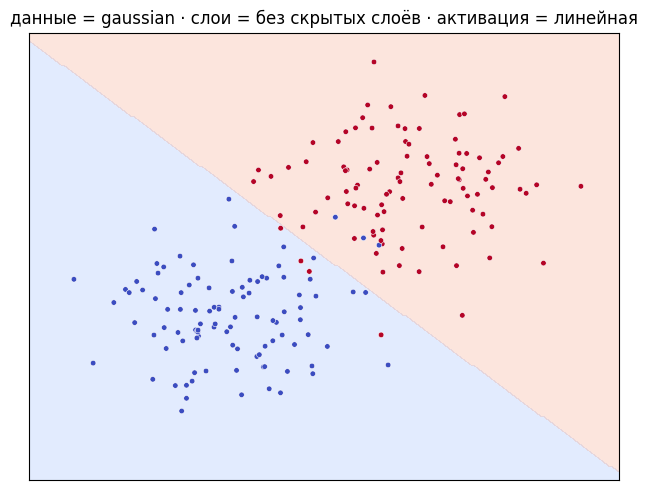

Точность на обучающей выборке: 96%
Точность на тестовой выборке:  96%


In [6]:
# Линейная модель (без скрытого слоя) на ЛИНЕЙНО РАЗДЕЛИМЫХ данных
DATASET = "gaussian"        # Измените параметр: попробуйте потом "circle"

show_result(dataset=DATASET, hidden=(), activation="линейная")

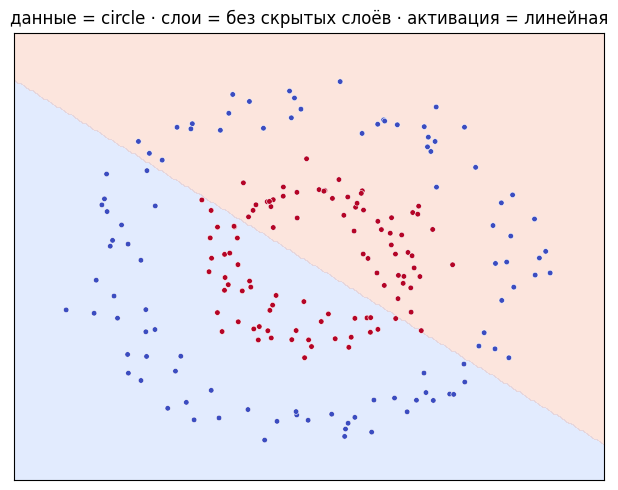

Точность на обучающей выборке: 54%
Точность на тестовой выборке:  47%


In [32]:
# Та же линейная модель, но на КОЛЬЦЕ — прямая не справляется
show_result(dataset="circle", hidden=(), activation="линейная")

---
## Эксперимент 2. Роль нелинейных функций активации

**Цель эксперимента.** Показать, что наличие скрытых слоёв само по себе не обеспечивает способность модели решать сложные задачи. Ключевую роль играет нелинейная функция активации.

**Ход работы.** Для набора данных `circle` используется сеть со скрытым слоем. Сначала применяется функция активации `tanh`, затем — линейная активация при сохранении той же архитектуры.

**Ожидаемый результат.** При использовании `tanh` сеть строит нелинейную разделяющую границу и успешно решает задачу. При линейной активации качество существенно ухудшается, несмотря на наличие нескольких слоёв.

**Вопросы для анализа.**
- Почему несколько линейных преобразований эквивалентны одному линейному преобразованию?
- Каким образом нелинейность увеличивает выразительную способность модели?

> Нелинейные функции активации позволяют сети представлять сложные зависимости, которые невозможно описать одной прямой линией.


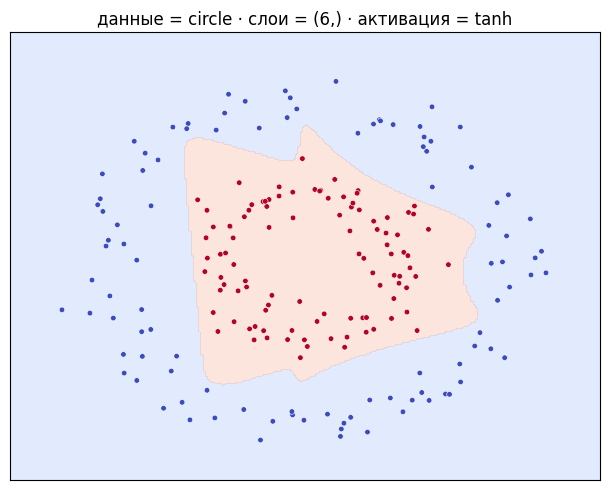

Точность на обучающей выборке: 100%
Точность на тестовой выборке:  98%


In [33]:
# Скрытый слой + НЕЛИНЕЙНАЯ активация — кольцо решается
ACTIVATION = "tanh"           # Измените параметр: попробуйте "ReLU", "сигмоида", "линейная"

show_result(dataset="circle", hidden=(6,), activation=ACTIVATION)

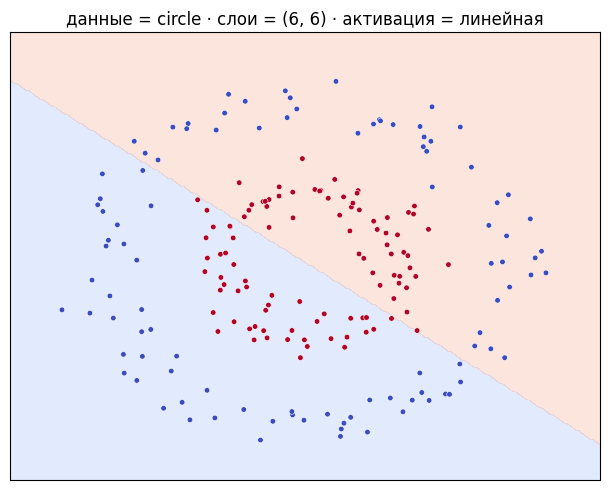

Точность на обучающей выборке: 54%
Точность на тестовой выборке:  47%


In [34]:
# Те же скрытые слои, но активация ЛИНЕЙНАЯ — слои не помогают
show_result(dataset="circle", hidden=(6, 6), activation="линейная")

---
## Эксперимент 3. Процесс обучения и скорость обучения

**Цель эксперимента.** Исследовать динамику уменьшения функции потерь и понять влияние параметра learning rate.

**Ход работы.** В первой части эксперимента наблюдается изменение функции потерь по эпохам. Во второй части сравниваются несколько значений learning rate.

**Ожидаемый результат.**
- Слишком большое значение learning rate приводит к нестабильному обучению.
- Слишком маленькое значение learning rate делает обучение чрезмерно медленным.
- Промежуточные значения обеспечивают устойчивую сходимость.

**Вопросы для анализа.**
- Почему чрезмерно большой шаг может препятствовать нахождению минимума?
- Как определить, что обучение происходит слишком медленно?

> Подбор гиперпараметров является неотъемлемой частью разработки нейросетевых моделей.


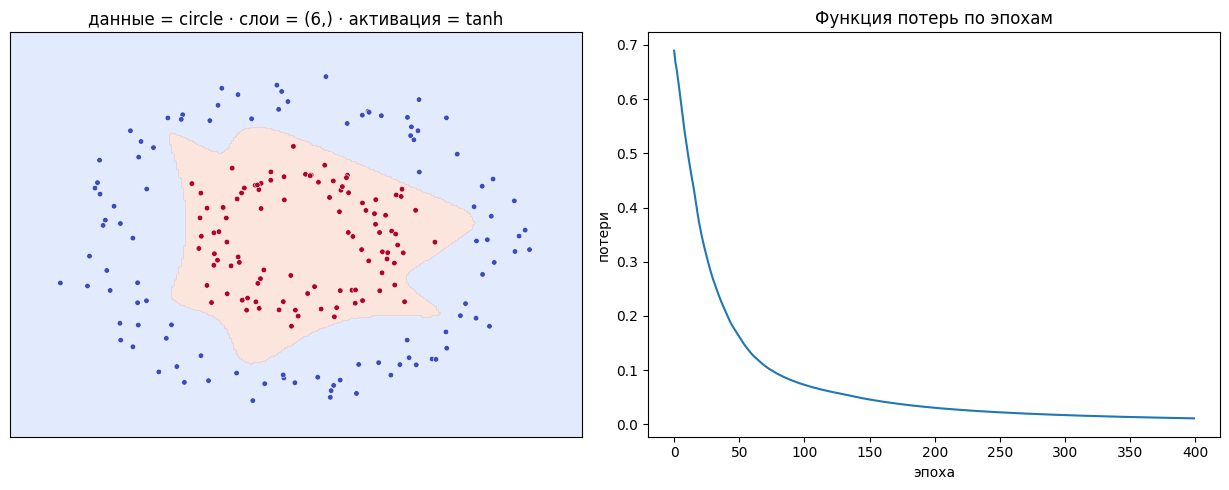

Точность на обучающей выборке: 100%
Точность на тестовой выборке:  98%


In [35]:
# Кривая ошибки: видно, как сеть шаг за шагом спускается с "горы ошибки"
show_result(dataset="circle", hidden=(6,), activation="tanh",learning_rate=0.1, max_iter=400, show_loss=True)

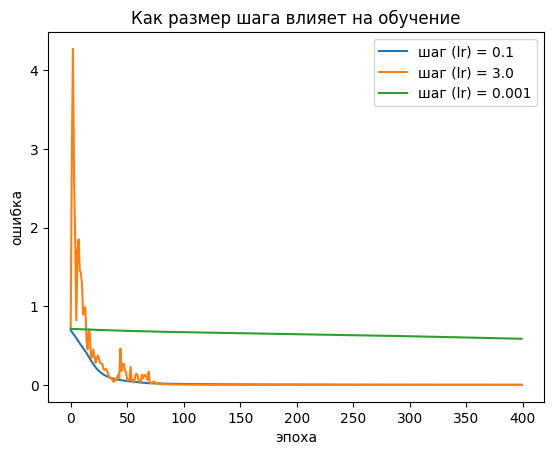

In [36]:
# Сравнение размеров шага (learning rate)
for lr in [0.1, 3.0, 0.001]:          # Измените параметр: попробуйте свои значения
    plt.plot(loss_curve_for(lr), label=f"шаг (lr) = {lr}")
plt.xlabel("эпоха"); plt.ylabel("ошибка")
plt.title("Как размер шага влияет на обучение"); plt.legend(); plt.show()

---
## Эксперимент 4. Переобучение и регуляризация

**Цель эксперимента.** Понять различие между способностью модели запоминать обучающие данные и способностью обобщать знания на новые примеры.

**Ход работы.** Используется сложный набор данных `spiral`, небольшой объём обучающей выборки и сеть с большим числом параметров. Затем добавляется L2-регуляризация.

**Ожидаемый результат.**
- Без регуляризации модель достигает очень высокой точности на обучающих данных, но заметно хуже работает на тестовых данных.
- После добавления регуляризации качество на тестовой выборке улучшается, а разрыв между метриками уменьшается.

**Вопросы для анализа.**
- Почему высокая точность на обучающей выборке не гарантирует успешную работу модели на новых данных?
- Каким образом регуляризация снижает риск переобучения?

> При оценке качества модели приоритет всегда следует отдавать результатам на независимой тестовой выборке.


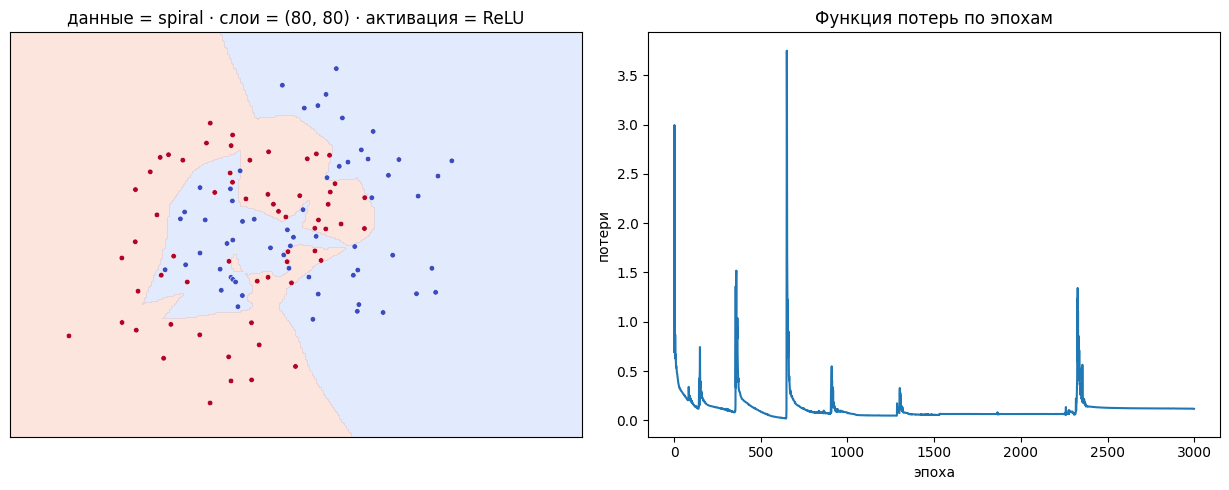

Точность на обучающей выборке: 94%
Точность на тестовой выборке:  75%


In [37]:
# Большая сеть на сложных данных с шумом -> ПЕРЕОБУЧЕНИЕ
L2 = 0.0                      # Измените параметр: попробуйте потом 1.0

show_result(dataset="spiral", hidden=(80, 80), activation="ReLU",
            noise=0.2, train_ratio=0.3, l2=L2, max_iter=3000, show_loss=True)

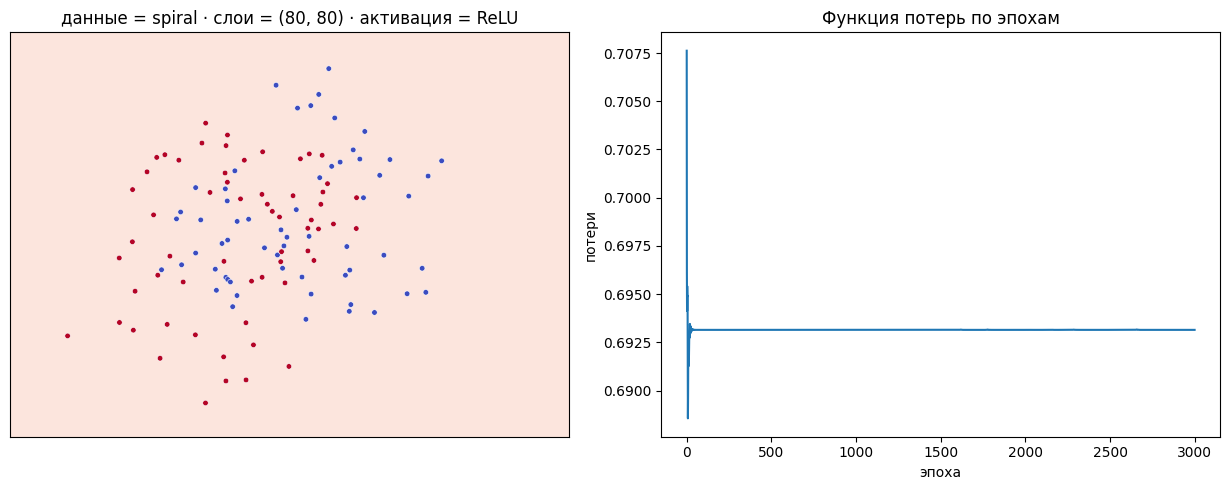

Точность на обучающей выборке: 50%
Точность на тестовой выборке:  50%


In [38]:
# Та же сеть с регуляризацией L2 — разрыв обучающая/тестовая сокращается
show_result(dataset="spiral", hidden=(80, 80), activation="ReLU",
            noise=0.2, train_ratio=0.3, l2=1.0, max_iter=3000, show_loss=True)

---
## Эксперимент 5. Анализ прикладных сценариев

В данном разделе вычислительные эксперименты отсутствуют. Необходимо проанализировать предложенные практические задачи и определить, насколько оправдано применение нейронных сетей в каждом случае.

При обсуждении используйте следующие критерии:

1. Тип данных.
2. Объём доступной обучающей выборки.
3. Требования к интерпретируемости решений.
4. Наличие готовых программных решений.
5. Стоимость ошибки и ограничения предметной области.

Главная задача — аргументировать выбор метода, а не просто назвать конкретный алгоритм.


---
## Краткий справочник терминов

| Термин | Пояснение |
|--------|-----------|
| Нейрон | Базовый вычислительный элемент сети, выполняющий взвешенное суммирование входов и применение функции активации. |
| Вес | Параметр, определяющий влияние входного признака на результат. |
| Функция активации | Нелинейное преобразование, повышающее выразительную способность модели. |
| Скрытый слой | Набор нейронов между входом и выходом сети. |
| Функция потерь | Числовая мера ошибки модели. |
| Градиентный спуск | Метод оптимизации, направленный на уменьшение функции потерь. |
| Learning rate | Коэффициент, определяющий величину шага обновления параметров. |
| Эпоха | Один полный проход по обучающей выборке. |
| Переобучение | Ситуация, при которой модель хорошо работает на обучающих данных, но плохо обобщает новые примеры. |
| Обучающая выборка | Данные, используемые для настройки параметров модели. |
| Тестовая выборка | Независимые данные для оценки качества обобщения. |


---
## Домашнее задание

1. Подберите минимальную архитектуру сети, позволяющую успешно решить задачу `spiral`. Зафиксируйте архитектуру, функцию активации, значение learning rate и итоговые метрики.
2. Подготовьте краткое письменное заключение (5–7 предложений), в котором сформулируйте основные наблюдения, сделанные в ходе выполнения лабораторной работы.
3. **Отправьте решение на мудл до 23:55, 18.06.2026**

---
## Сводная таблица экспериментов

Ниже приведены рекомендуемые конфигурации для воспроизведения основных эффектов, рассматриваемых в ходе занятия.

| Эксперимент | Набор данных | Архитектура | Активация | Особенности | Основное наблюдение |
|---|---|---|---|---|---|
| 1 | gaussian → circle | Без скрытых слоёв | линейная | — | Линейная модель работает только для линейно разделимых данных |
| 2 | circle | Один или два скрытых слоя | tanh / линейная | — | Нелинейность существенно повышает выразительную способность сети |
| 3 | circle | Небольшая сеть | tanh | Изменение learning rate | Скорость обучения влияет на сходимость |
| 4 | spiral | Глубокая сеть | ReLU | Шум и регуляризация | Демонстрация переобучения и способов борьбы с ним |


---------------------------------------------------------------

# Решение Домашнего задания

## Подготовка

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from   sklearn.model_selection import train_test_split
from   sklearn.datasets import make_circles, make_blobs
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

ACT = {
    "линейная": nn.Identity,
    "ReLU": nn.ReLU,
    "tanh": nn.Tanh,
    "сигмоида": nn.Sigmoid
}

def make_dataset(kind, n=400, noise=0.1):
    kind = kind.lower()
    if kind == "gaussian":
        X, y = make_blobs(
            n_samples=n,
            centers=[[-2.2, -2.2], [2.2, 2.2]],
            cluster_std=1.4 + 3 * noise,
            random_state=0
        )
    elif kind == "circle":
        X, y = make_circles(n_samples=n, noise=noise, factor=0.45, random_state=0)
        X *= 4
    elif kind == "xor":
        r = np.random.RandomState(7)
        X = r.uniform(-4, 4, (n, 2))
        y = ((X[:, 0] > 0) ^ (X[:, 1] > 0)).astype(int)
        X += noise * r.randn(n, 2) * 4
    elif kind == "spiral":
        r = np.random.RandomState(7)
        n2 = n // 2
        t = np.linspace(0.3, 1, n2) * 2.5 * np.pi
        rr = np.linspace(0.25, 4, n2)
        xa = np.c_[rr * np.cos(t), rr * np.sin(t)]
        xb = np.c_[rr * np.cos(t + np.pi), rr * np.sin(t + np.pi)]
        X = np.concatenate([xa, xb])
        y = np.array([0] * n2 + [1] * n2)
        X += noise * r.randn(*X.shape) * 4
    else:
        raise ValueError("Неизвестный набор данных: " + kind)
    return X.astype(np.float32), y.astype(np.float32)

class MLP(nn.Module):
    def __init__(self, hidden, activation):
        super().__init__()
        layers = []
        in_features = 2

        if len(hidden) == 0:
            layers.append(nn.Linear(2, 1))
        else:
            for h in hidden:
                layers.extend([nn.Linear(in_features, h), activation()])
                in_features = h
            layers.append(nn.Linear(in_features, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_model(Xtr, ytr, hidden, activation, learning_rate, l2, max_iter):
    model = MLP(hidden, ACT[activation])
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
    criterion = nn.BCEWithLogitsLoss()
    X_tensor = torch.tensor(Xtr)
    y_tensor = torch.tensor(ytr).view(-1, 1)

    losses = []
    for _ in range(max_iter):
        optimizer.zero_grad()
        logits = model(X_tensor)
        loss = criterion(logits, y_tensor)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    return model, losses

def accuracy(model, X, y):
    with torch.no_grad():
        pred = (torch.sigmoid(model(torch.tensor(X))) > 0.5).numpy().astype(int).ravel()
    return (pred == y.astype(int)).mean()

def show_result(dataset="circle", hidden=(4,), activation="tanh", learning_rate=0.1,
                noise=0.1, train_ratio=0.5, l2=0.0, max_iter=800,
                show_loss=False, title=None, seed=1):

    X, y = make_dataset(dataset, 400, noise)
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, train_size=train_ratio, random_state=seed, stratify=y.astype(int)
    )

    model, loss = train_model(
        Xtr, ytr, tuple(hidden), activation,
        learning_rate, l2, max_iter
    )

    tr = accuracy(model, Xtr, ytr)
    te = accuracy(model, Xte, yte)

    ncol = 2 if show_loss else 1
    fig, axs = plt.subplots(1, ncol, figsize=(6.2 * ncol, 5))
    axs = np.atleast_1d(axs)

    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 250),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 250)
    )

    with torch.no_grad():
        grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
        Z = (torch.sigmoid(model(torch.tensor(grid))) > 0.5).numpy()
        Z = Z.reshape(xx.shape)

    axs[0].contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    axs[0].scatter(Xtr[:,0], Xtr[:,1], c=ytr, cmap="coolwarm", s=16,
                   edgecolors="white", linewidths=0.4)
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    axs[0].set_title(
        title or f"данные = {dataset} · "
                 f"слои = {hidden or 'без скрытых слоёв'} · "
                 f"активация = {activation}"
    )

    if show_loss:
        axs[1].plot(loss)
        axs[1].set_title("Функция потерь по эпохам")
        axs[1].set_xlabel("эпоха")
        axs[1].set_ylabel("потери")

    plt.tight_layout()
    plt.show()

    return tr, te

## Подберем экспериментально параметры необходимые для достижения высокого уровня обучения на тренировочной и тестовой выборке

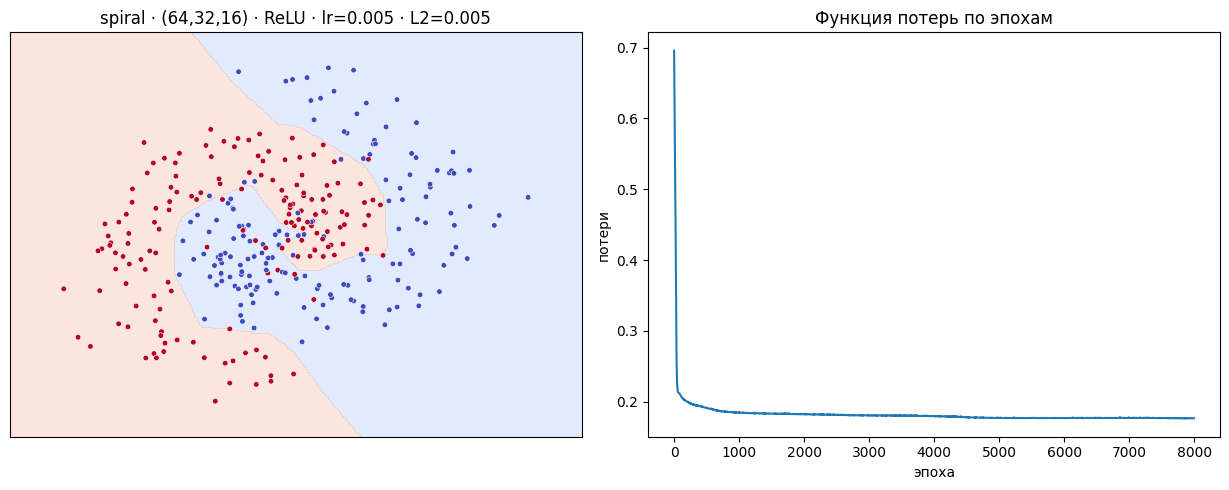

Точность на обучающей выборке: 93%
Точность на тестовой выборке:  91%
Разрыв между тренировочной и тестовой выборкой : 2%


In [60]:
train_acc, test_acc = show_result(

    # экспериментальный блок

    dataset       =     "spiral",
    hidden        =     (64, 32, 16),
    activation    =     "ReLU",
    learning_rate =     0.005,
    noise         =     0.15,
    train_ratio   =     0.8,
    l2            =     0.005,
    max_iter      =     8000,
    show_loss     =     True,
    title         =     "spiral · "
                        "(64,32,16) · "
                        "ReLU · "
                        "lr=0.005 · "
                        "L2=0.005"
)

print(f"Разрыв между тренировочной и тестовой выборкой : {train_acc - test_acc:.0%}")

### Выводы по результатам экспериментов :

------------------------------

В ходе выполнения работы были проведены
серии экспериментов с различными архитектурами,
функциями активации и гиперпараметрами.


### Финальная архитектура

В результате подбора была выбрана следующая архитектура:

| Параметр | Значение |
|----------|----------|
| **Скрытые слои** | (64, 32, 16) |
| **Функция активации** | ReLU |
| **Learning rate** | 0.005 |
| **L2-регуляризация** | 0.005 |
| **Количество эпох** | 8000 |
| **Доля обучающей выборки** | 80% |

**Итоговые метрики:**
- Точность на обучающей выборке: **93%**
- Точность на тестовой выборке: **91%**
- Разрыв между метриками: **2%**

---

### Что дало результат ?

1. Использование **нелинейной функции активации** (ReLU).
2. Применение **L2-регуляризации** для борьбы с переобучением.
3. Использование **достаточного количества данных** (80% на обучение).
4. Правильный подбор **learning rate** (0.005).

Полученные метрики (93% на обучении, 91% на тесте) подтверждают, что модель успешно обобщает и готова к применению на новых данных.